# Crop Yield Prediction using Machine Learning

## Data Loading & Initial Exploration

### Objective
Load the dataset, inspect its structure, understand the features, and perform an initial quality check.

In [5]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [6]:
# Load dataset

df = pd.read_csv("../data/raw/yield_df.csv")

In [7]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## Dataset Inspection

In this section, we inspect the dataset structure, dimensions, data types, missing values, and descriptive statistics before performing any preprocessing.

In [8]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 28242
Columns : 8


In [10]:
df.columns

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [16]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [17]:
missing = df.isnull().sum()

missing

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.dtypes

Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

In [20]:
df.sample(10, random_state=42)

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
25564,25564,Spain,"Rice, paddy",2008,69220,636.0,40719.00,17.21
18113,18113,Madagascar,Wheat,1996,20000,1513.0,152.01,19.71
25607,25607,Spain,Sorghum,2010,51206,636.0,39043.00,16.51
6815,6815,Colombia,Potatoes,2007,166986,3240.0,82439.06,27.45
18144,18144,Madagascar,Sweet potatoes,2000,56319,1513.0,130.46,19.65
12680,12680,India,"Rice, paddy",2002,26163,1083.0,42482.56,26.66
3474,3474,Brazil,"Rice, paddy",1999,30708,1761.0,127585.00,25.88
22381,22381,Pakistan,Sweet potatoes,2000,109771,494.0,27885.00,27.12
20656,20656,Morocco,Potatoes,2004,241650,346.0,15064.00,18.21
23170,23170,Papua New Guinea,Sweet potatoes,1992,47500,3142.0,121.00,25.30


In [21]:
# Data validation report 
validation = pd.DataFrame({
    "Data Type":df.dtypes,
    "Missing Values":df.isnull().sum(),
    "Unique Values":df.nunique()
})

validation

,Data Type,Missing Values,Unique Values
Unnamed: 0,int64,0,28242
Area,object,0,101
Item,object,0,10
Year,int64,0,23
hg/ha_yield,int64,0,11514
average_rain_fall_mm_per_year,float64,0,100
pesticides_tonnes,float64,0,1673
avg_temp,float64,0,1831


In [22]:
#- Export Data Dictionary

data_dictionary = pd.DataFrame({
    "Column Name":df.columns,
    "Data Type":df.dtypes.values
})

data_dictionary.to_csv(
    "../data/processed/data_dictionary.csv",
    index=False
)

data_dictionary

,Column Name,Data Type
0,Unnamed: 0,int64
1,Area,object
2,Item,object
3,Year,int64
4,hg/ha_yield,int64
5,average_rain_fall_mm_per_year,float64
6,pesticides_tonnes,float64
7,avg_temp,float64


# Data Cleaning

### Objective
Handle missing values, remove unnecessary columns, detect duplicate records, identify outliers, correct data types, and export the cleaned dataset.

In [23]:
df_clean = df.copy()

In [24]:
#Remove Unnecessary Column

df_clean.drop(columns=["Unnamed: 0"], inplace=True)

df_clean.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [25]:
#Missing Values
df_clean.isnull().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

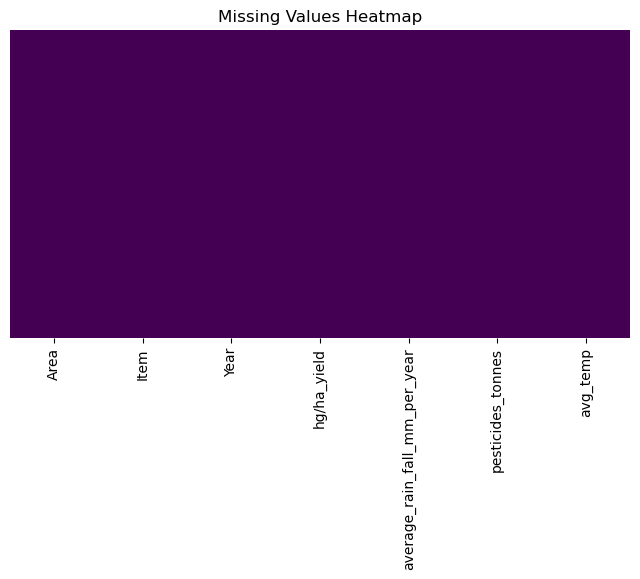

In [27]:
#Missing Value Heatmap
plt.figure(figsize=(8,4))

sns.heatmap(
    df_clean.isnull(),
    yticklabels=False,
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

Observation:
The dataset contains no missing values. The missing value heatmap confirms that all features are complete, so no imputation techniques were required.

In [29]:
# Remove duplicate rows

print("Before:", df_clean.shape)

df_clean.drop_duplicates(inplace=True)

print("After :", df_clean.shape)

Before: (28242, 7)
After : (25932, 7)


In [30]:
df_clean.duplicated().sum()

np.int64(0)

## Outlier Detection

In [31]:
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

numerical_columns

Index(['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

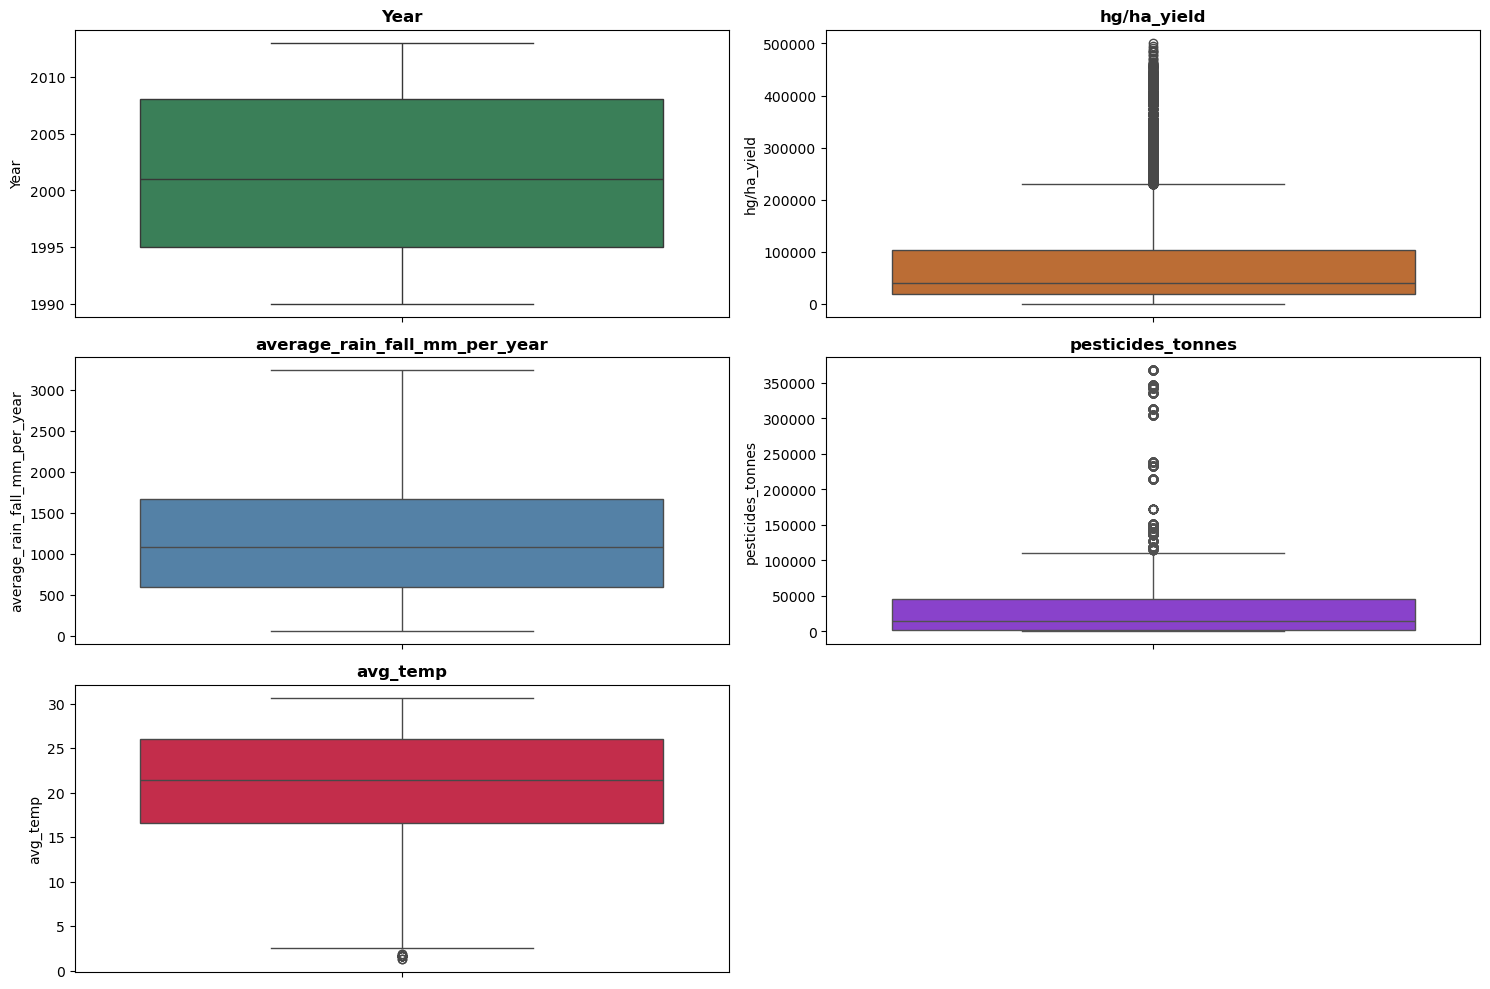

In [ ]:
# boxplot 

colors = [
    "#2E8B57",  # Year
    "#C97B3D",  # Yield
    "#5F9EA0",  # Rainfall
    "#8E44AD",  # Pesticides
    "#C72C48"   # Temperature
]

plt.figure(figsize=(16, 10))

for i, column in enumerate(numerical_columns):

    plt.subplot(3, 2, i + 1)

    sns.boxplot(
        y=df_clean[column],
        color=colors[i],
        width=0.5,
        linewidth=1.5,
        boxprops=dict(edgecolor="black"),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(
            marker="o",
            markersize=3,
            markerfacecolor="#444444",
            markeredgecolor="#444444",
            alpha=0.5
        )
    )

    plt.title(column.replace("_", " ").title(),
              fontsize=13,
              fontweight="bold")

    plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# IQR
for column in numerical_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower) |
        (df_clean[column] > upper)
    ]

    print(f"{column}: {len(outliers)} outliers")

Year: 0 outliers
hg/ha_yield: 1918 outliers
average_rain_fall_mm_per_year: 0 outliers
pesticides_tonnes: 1262 outliers
avg_temp: 16 outliers


### Observation

- No outliers were detected in Year, Rainfall and Average Temperature.
- Outliers were detected in Crop Yield and Pesticide Usage.
- These values were retained because they represent realistic agricultural variations rather than data entry errors.
- Tree-based machine learning models used later in the project are robust to such observations.

In [35]:
# Export
df_clean.to_csv(
    "../data/processed/cleaned_crop_yield.csv",
    index=False
)